# Download ข้อมูลจาก Scopus.com
* ใช้ email มมส ของนิสิต สมัคร และ Login

* เป้าหมายคือค้นหาบทความที่เกี่ยวข้องกับ Subject area คือ `Computer Science`

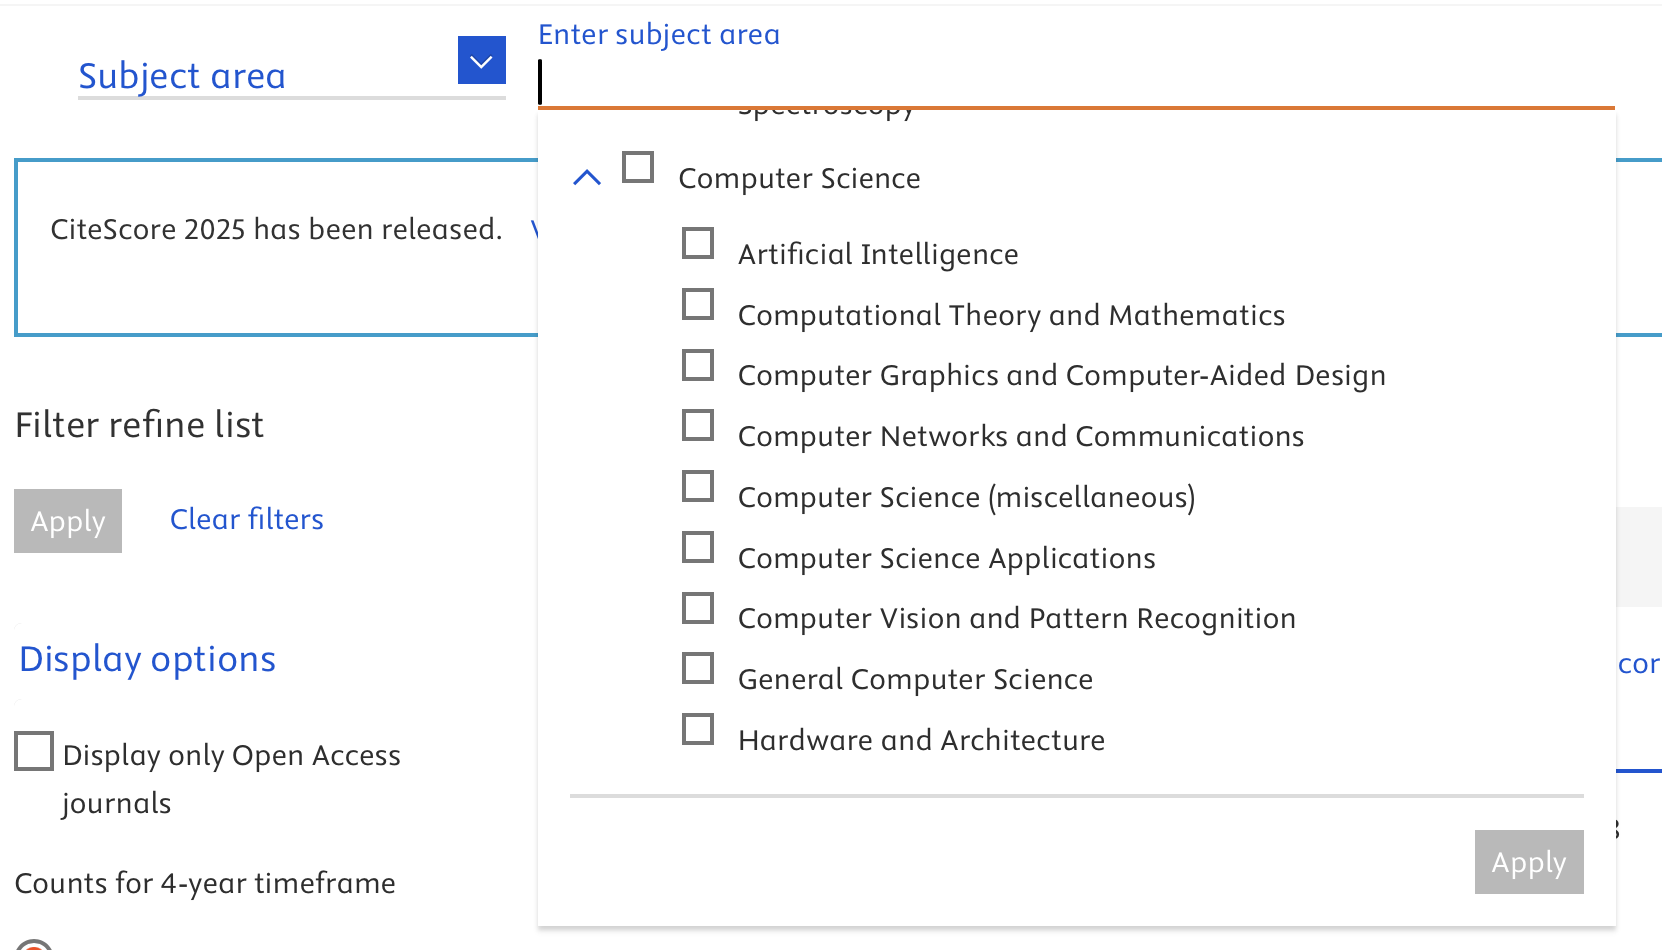

* ในหน้าหลักของ Scopus ให้ค้นหาโดยใช้ keyword เช่น `Artificial Intelligence`, `Computational Theory and Mathematics` เป็นต้น

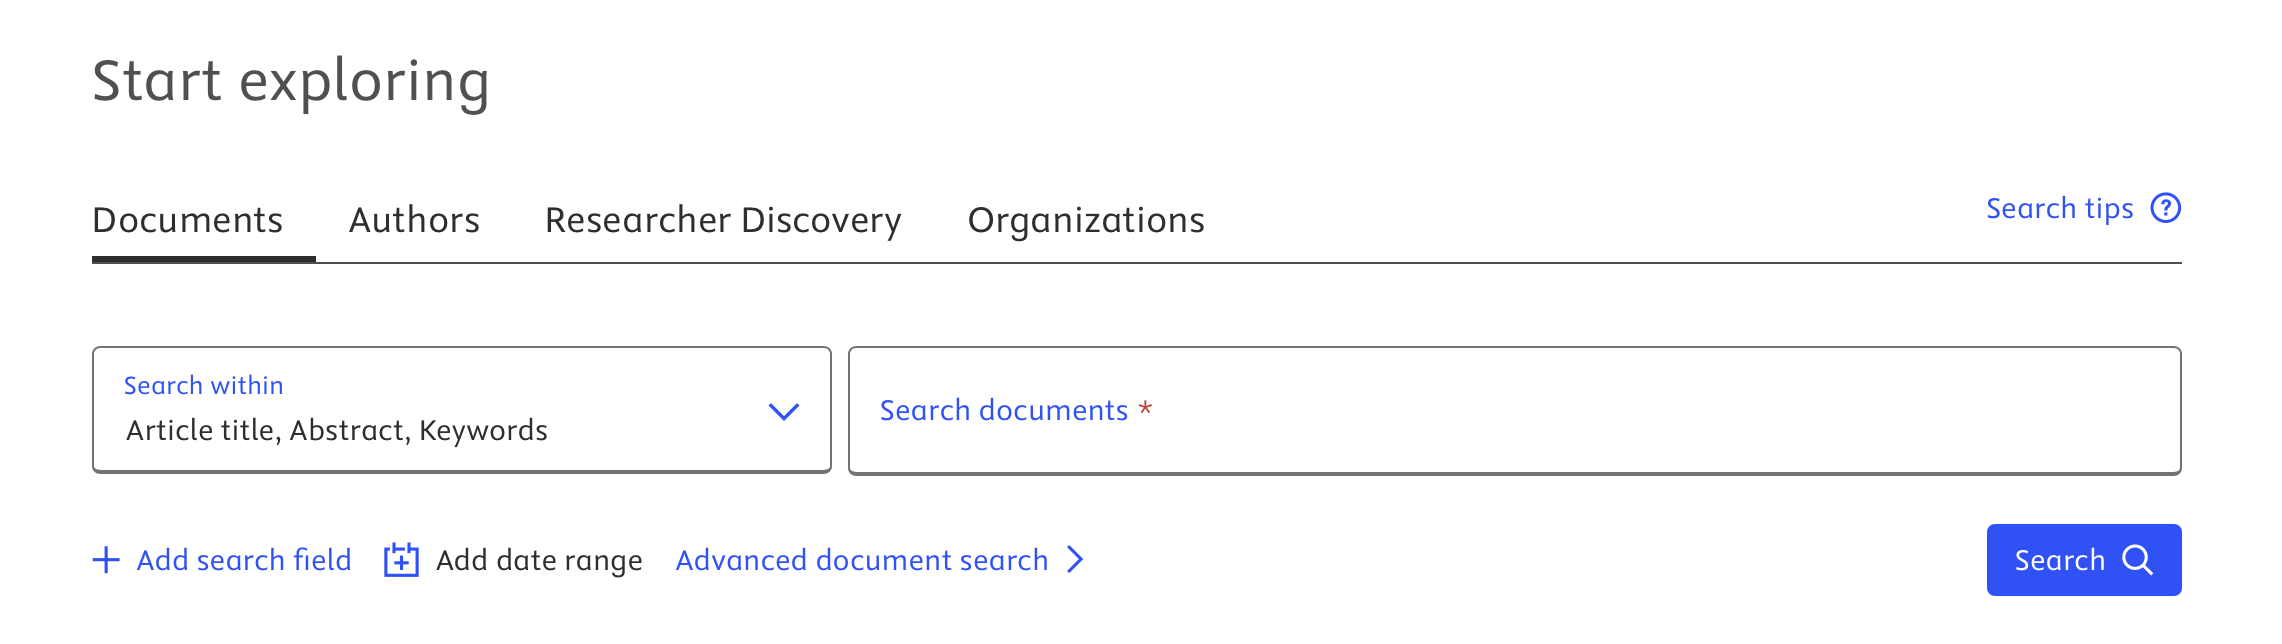

* ตัวอย่างค้นหา `artificial intelligence`

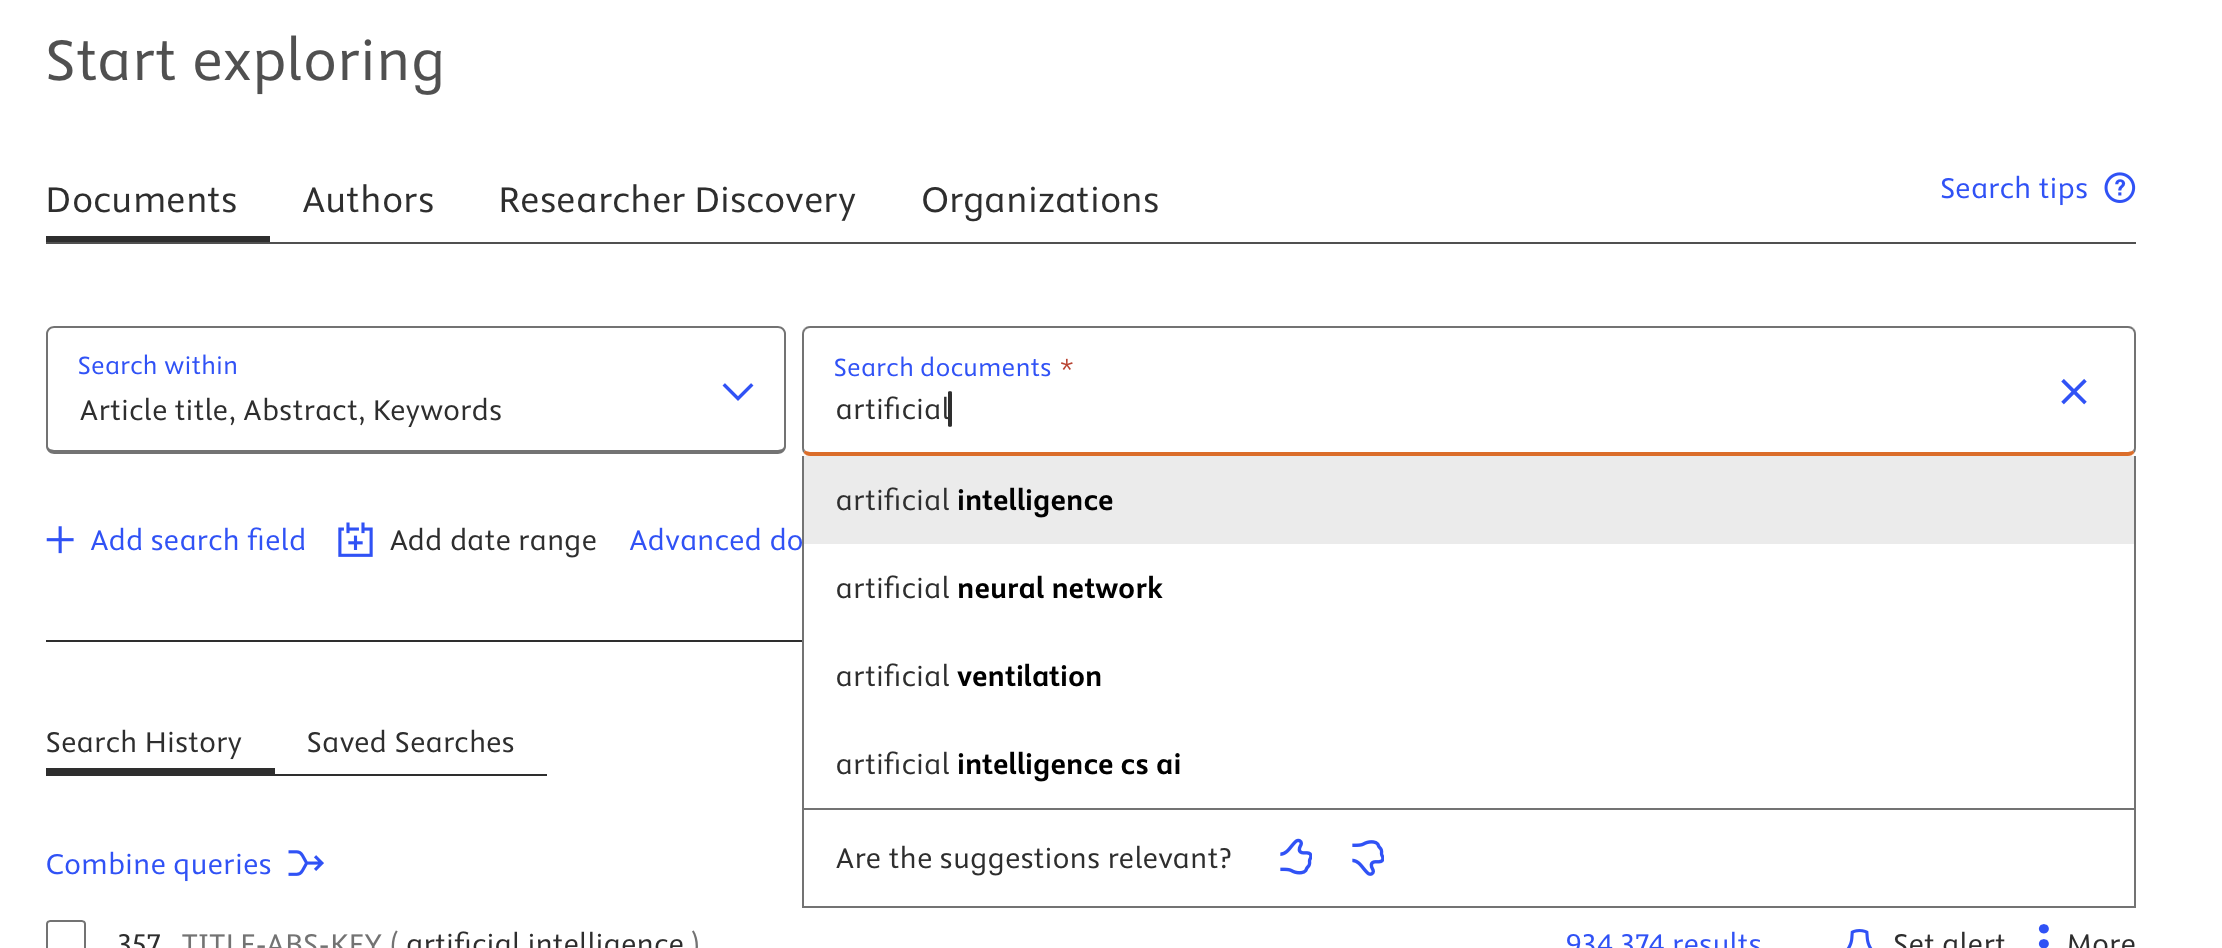

* ผลลัพธ์ที่ได้จากการค้นหา

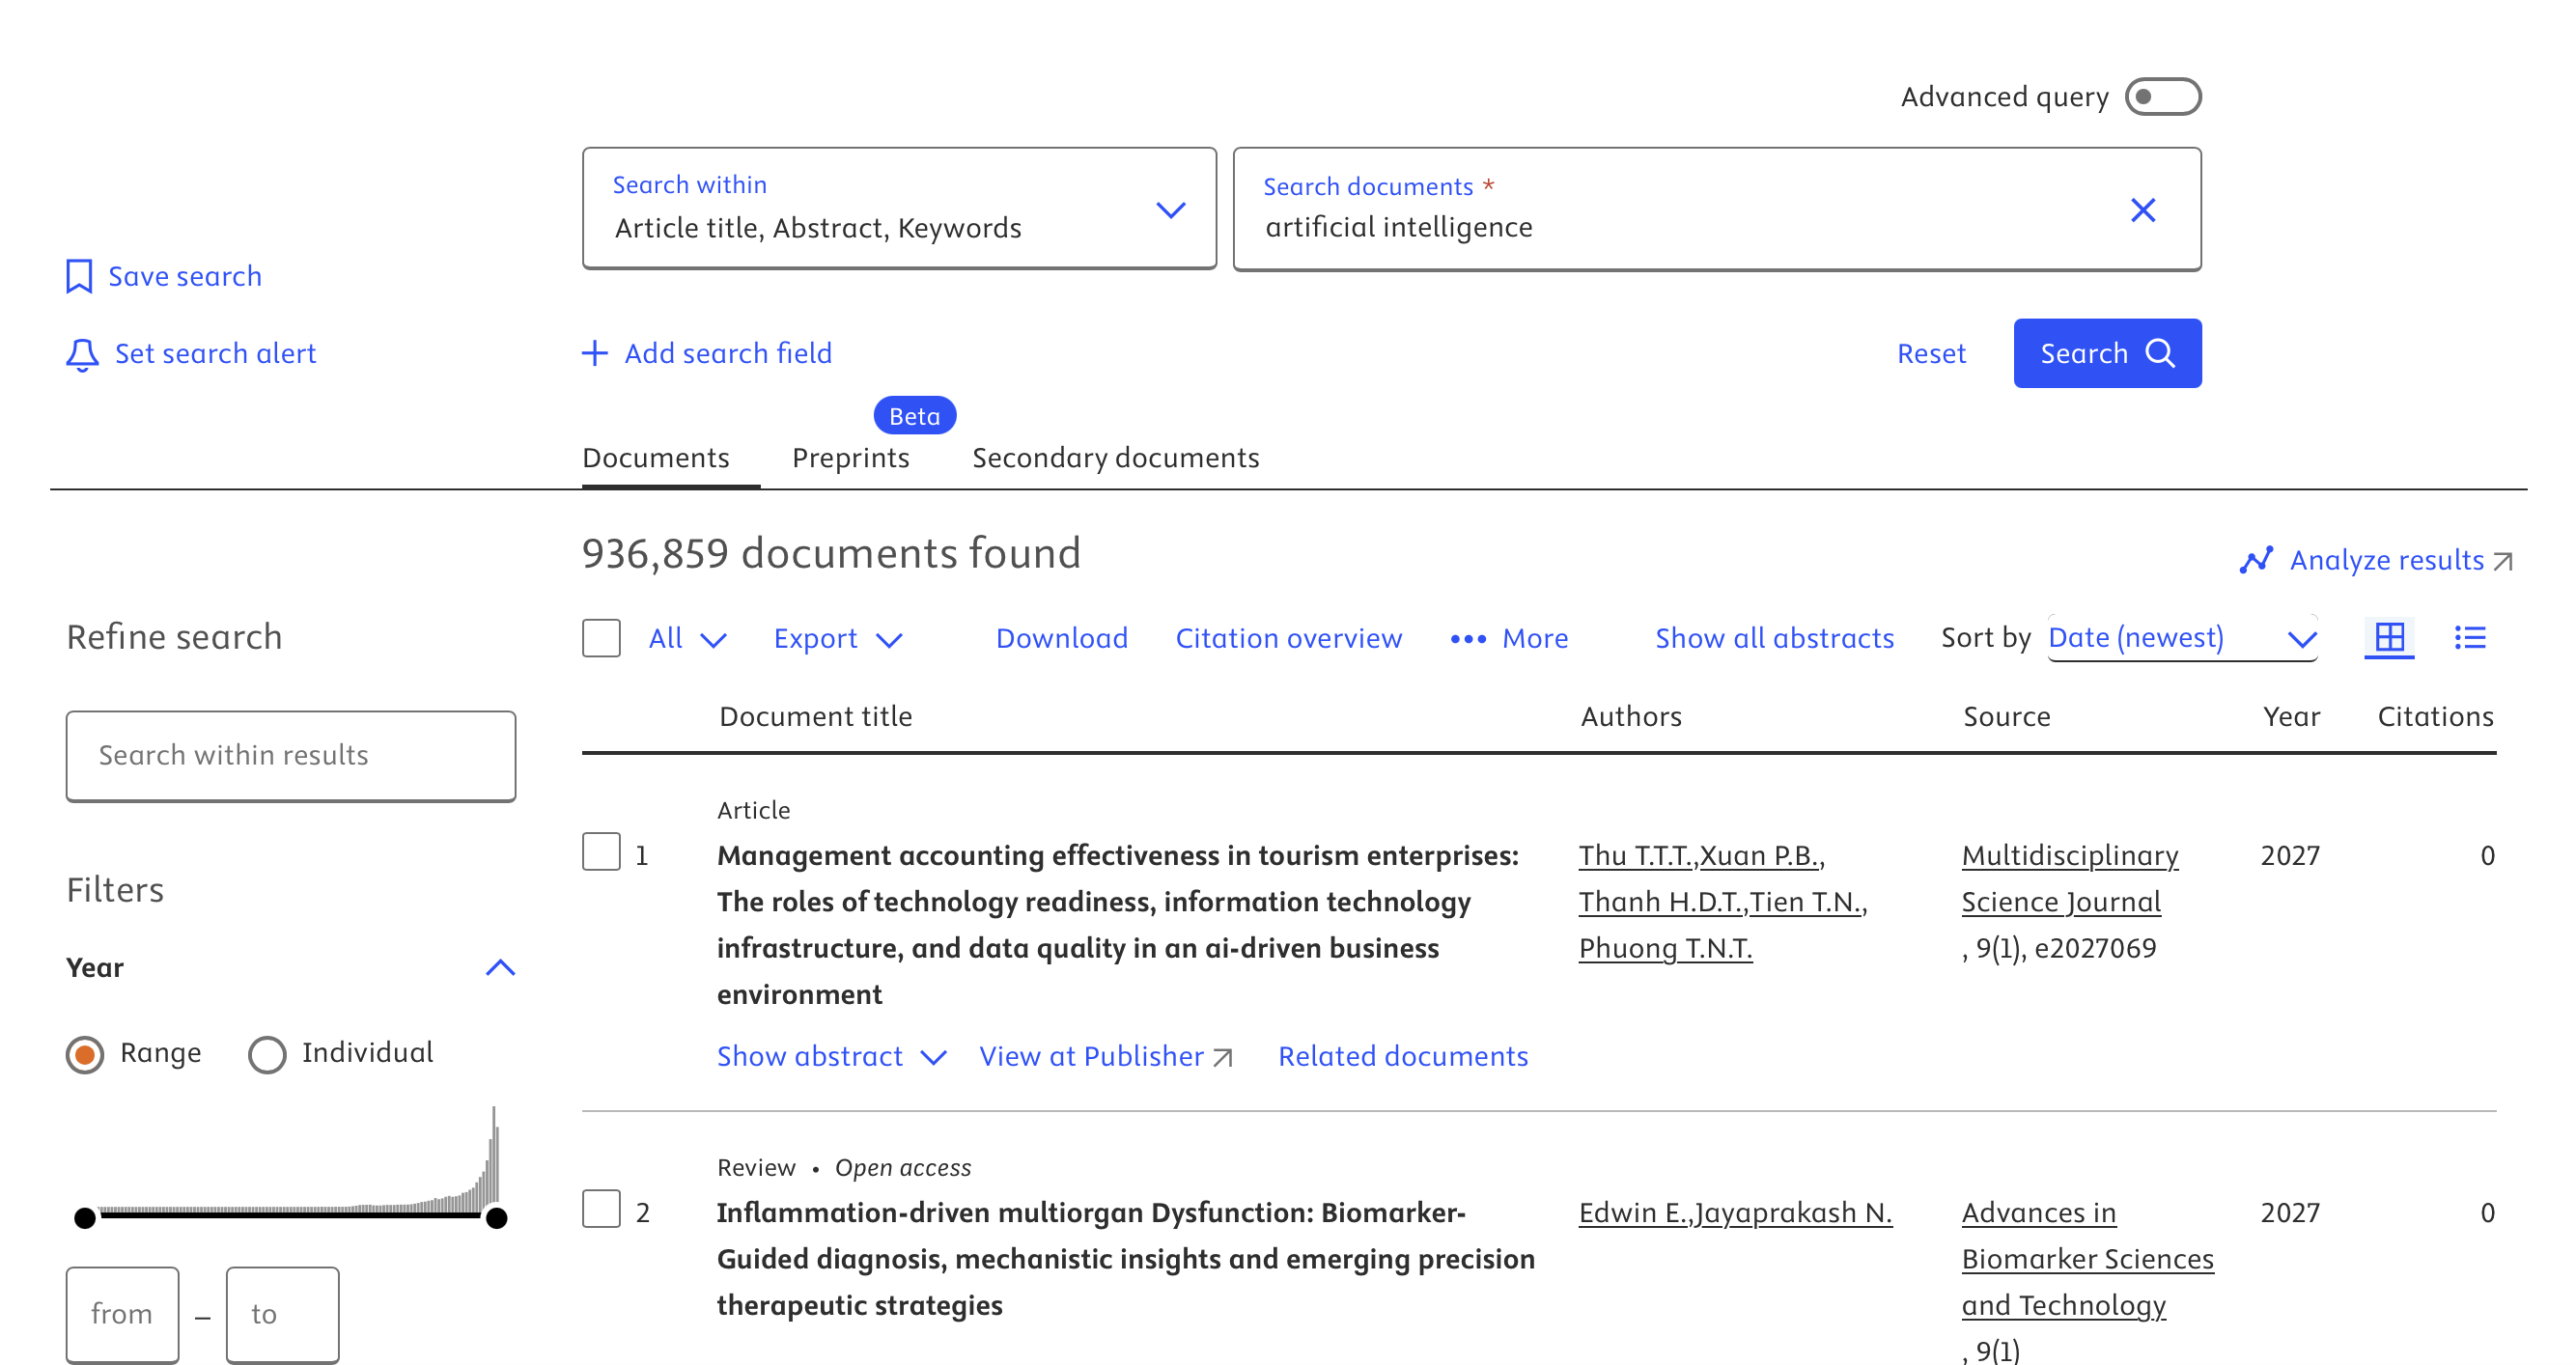

* สามารถปรับแก้การค้นหาโดยการ `Refine search`

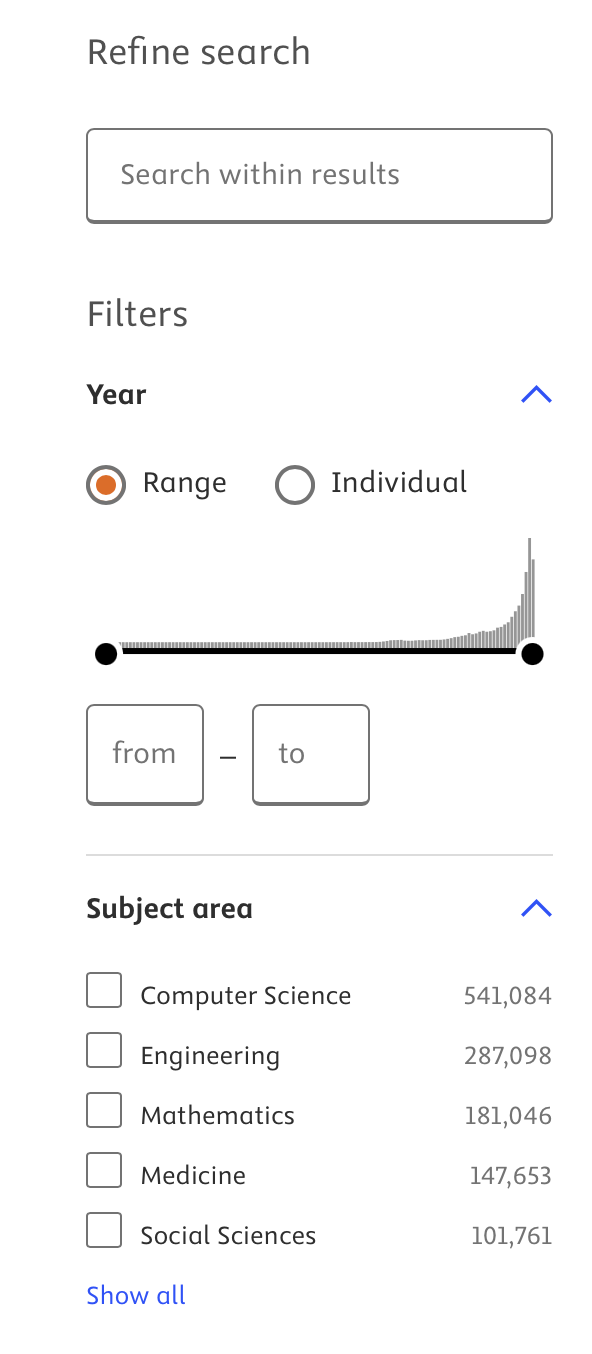

* ดาวน์โหลดข้อมูลด้วยการกดที่ปุ่ม `Export` และเลือก `csv`

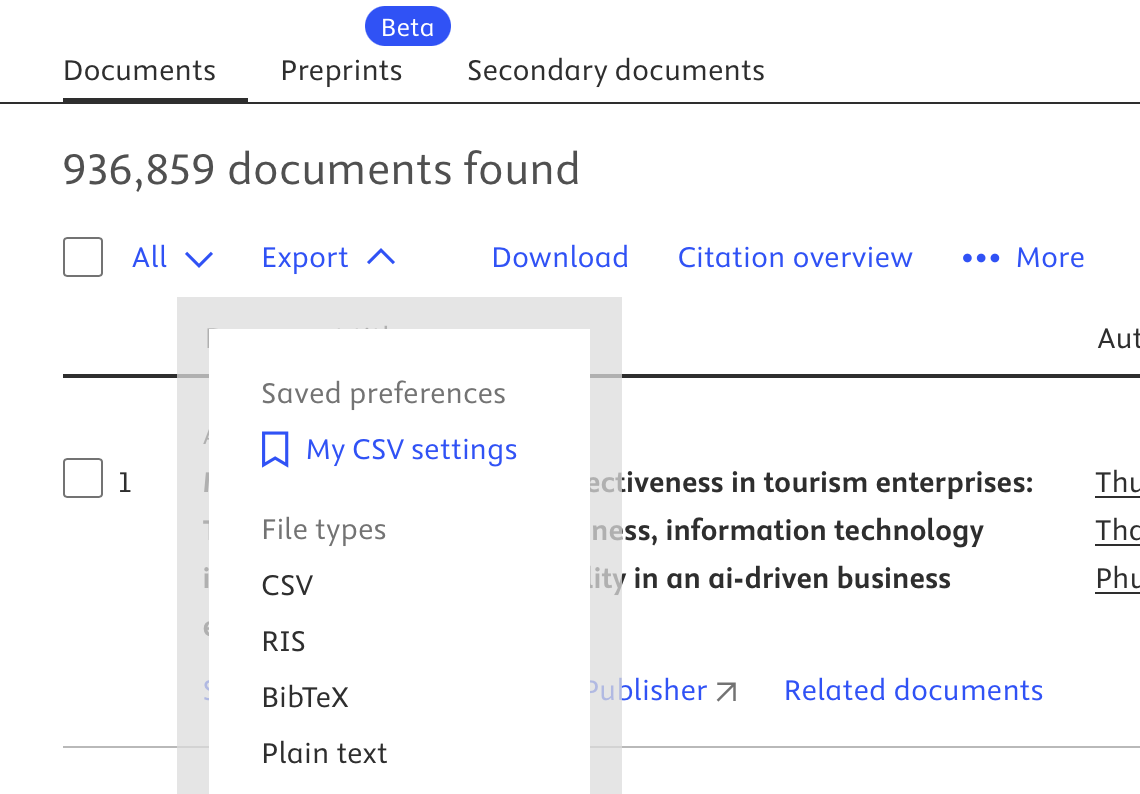

* จากนั้นเลือกข้อมูลที่ต้องการดาวน์โหลด

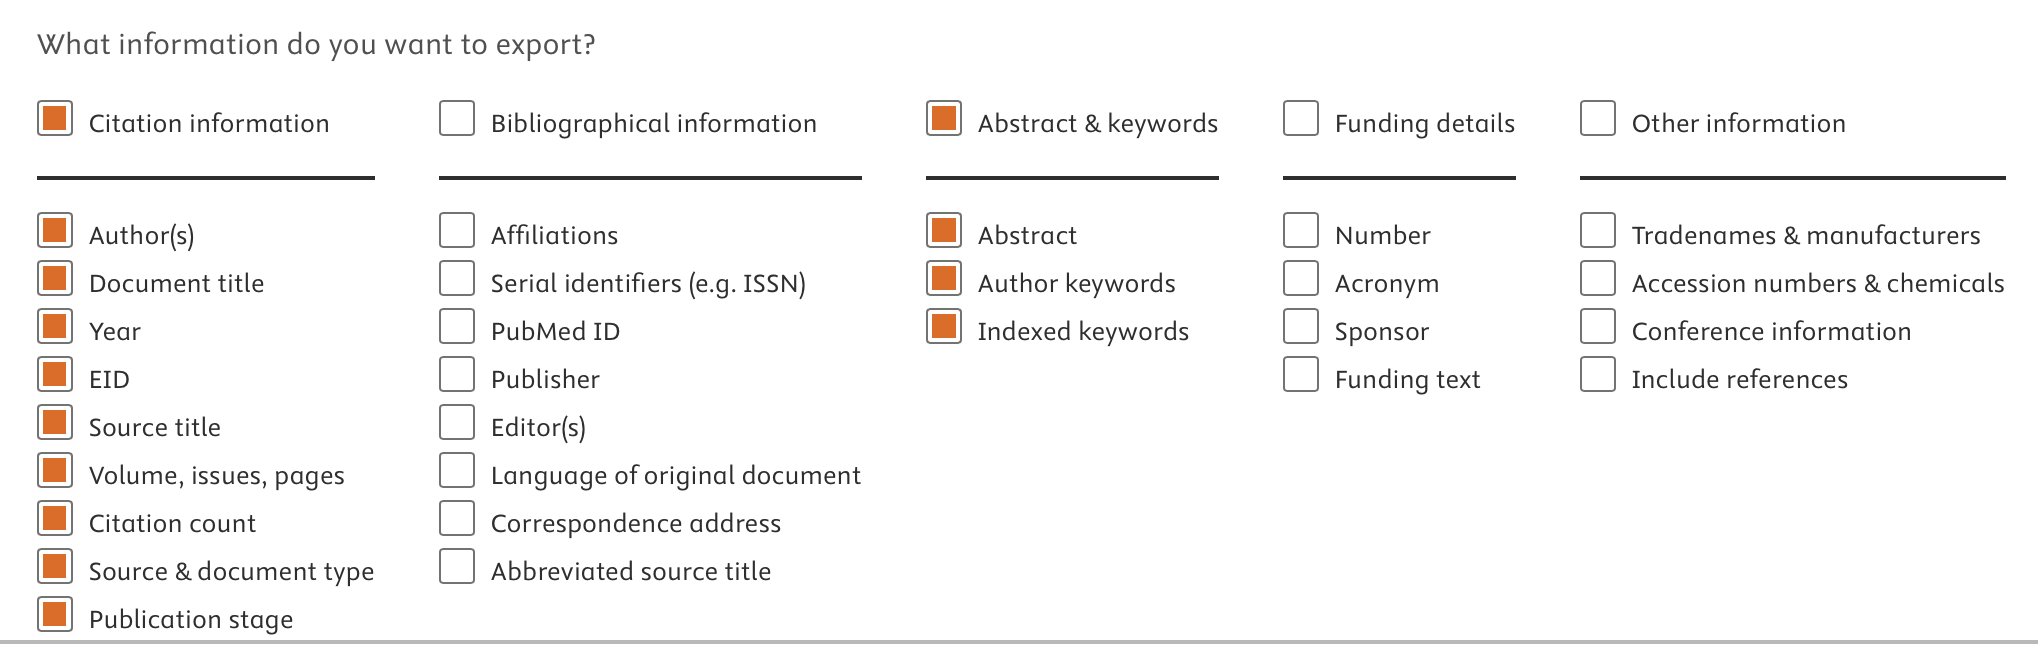

# โจทย์ งานกลุ่ม (กลุ่มละ 5 คน)

* ให้นิสิตโหลดข้อมูลจาก Scopus ทำ EDA, Visualization และเตรียมชุดข้อมูลเพื่อนำไปใช้ใน Machine Learning
* เตรียมทำ Slide ขั้นตอนการทำ EDA, Visualization และอื่น ๆ เพื่อให้เห็นว่าในกลุ่มของนิสิตมีกระบวนการอะไรบ้างในการเตรียมข้อมูลสำหรับนำไป Train ด้วย ML หรือเรียกว่า Feature Vector
* ตัวอย่างหนึ่งของการทำ Visualization: https://mrolarik.github.io/keyword-co-occurrence-network/



Keywork Co-occurrence Network

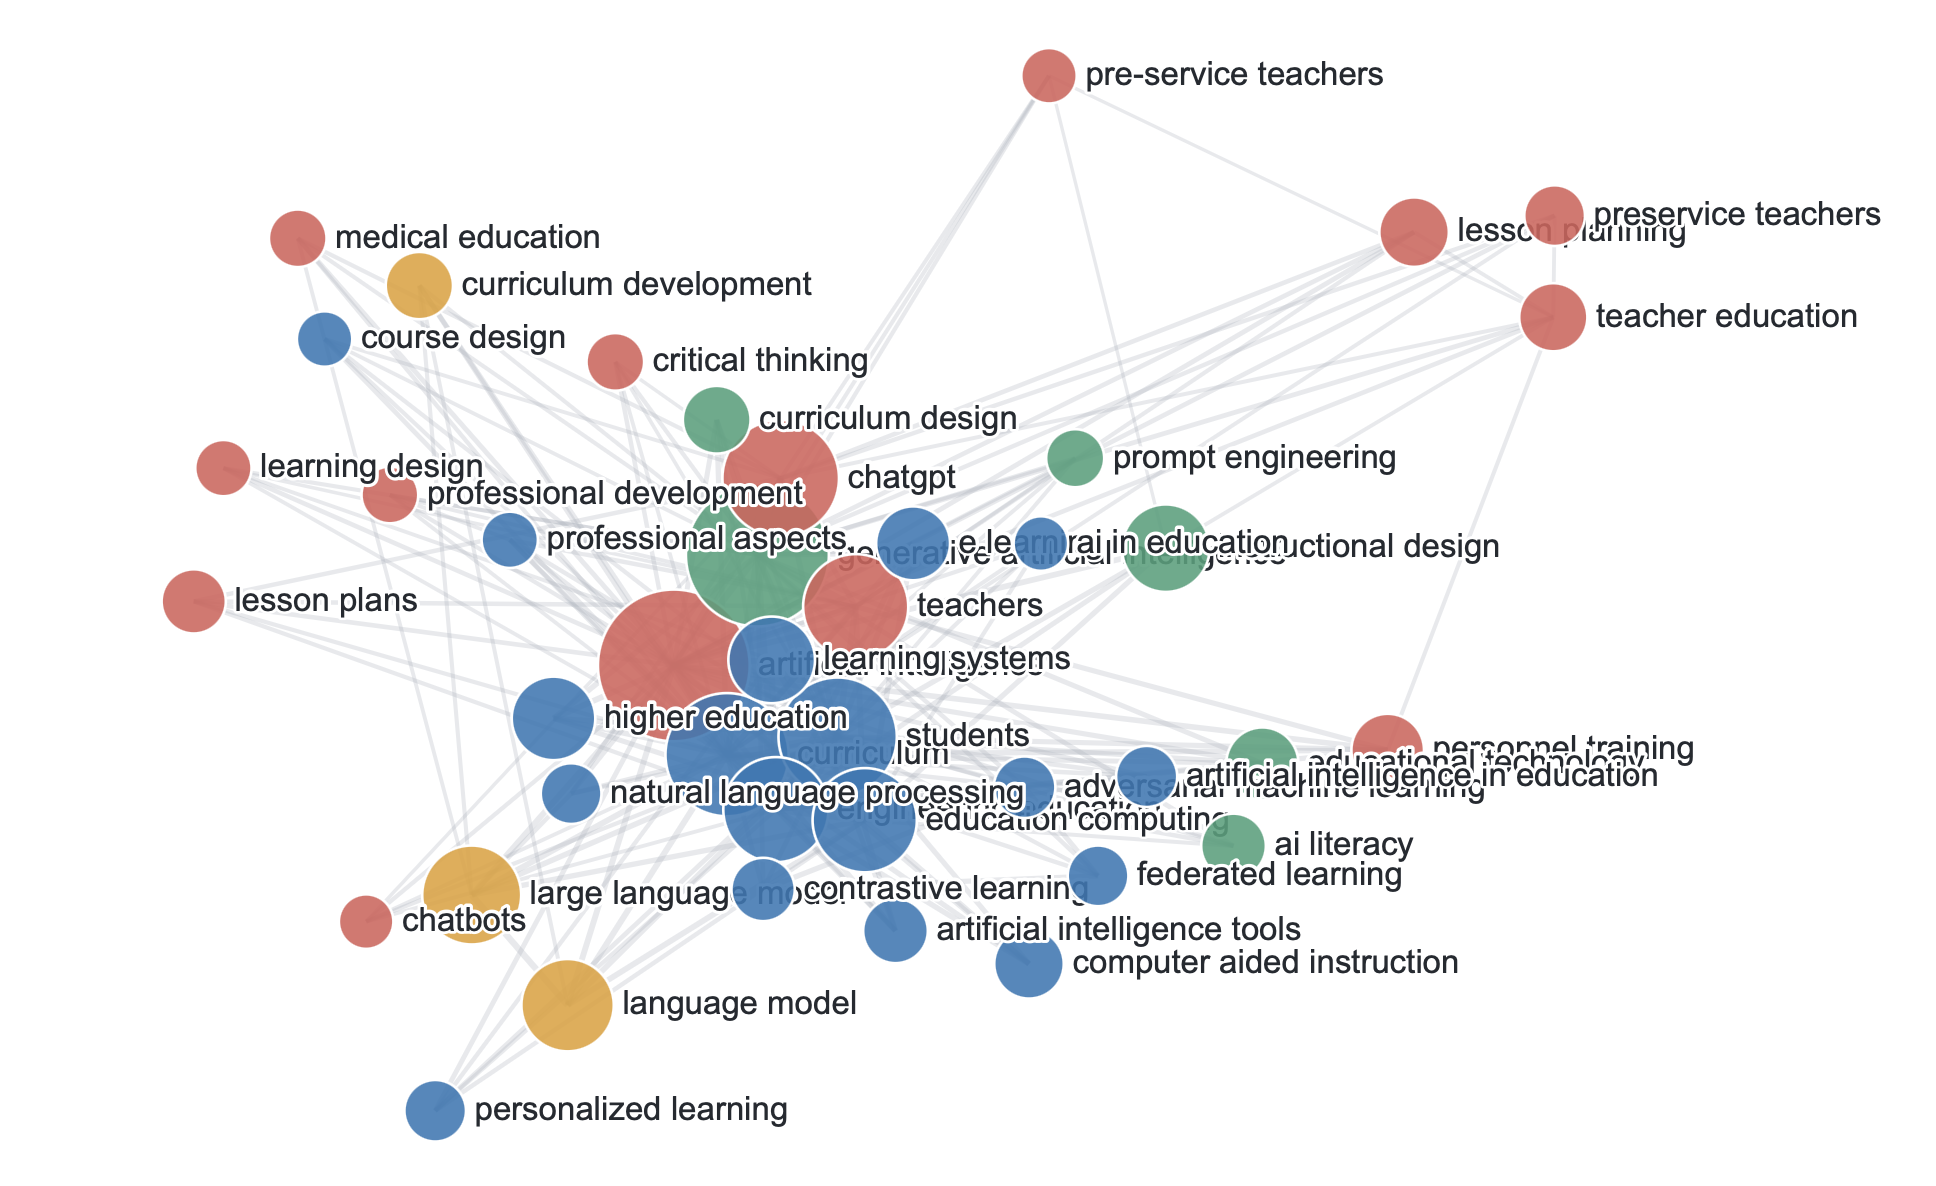

* ให้นิสิตค้นหาข้อมูล โดยใช้ keyword ประกอบด้วย Subject 10 รายการ ดังต่อไปนี้

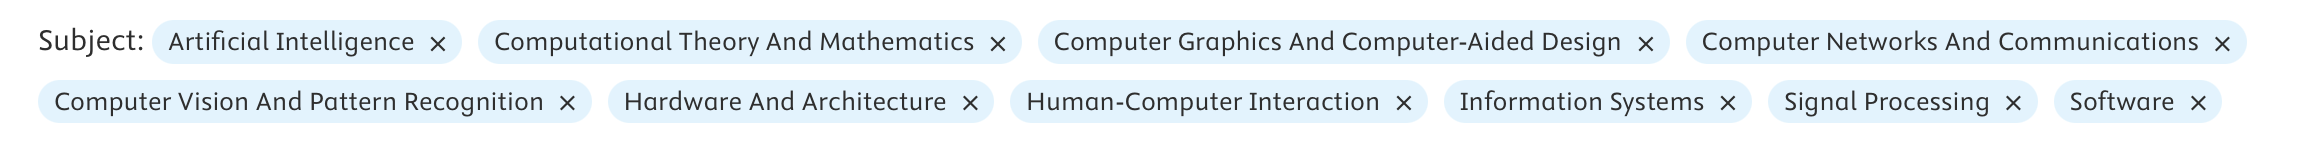

* โดยให้เลือกดาวน์โหลดข้อมูล Subject ละ 600 รายการ

เพิ่มเติมคือ เมื่อค้นโดยใช้ keyword ที่กำหนดจากนั้นให้เลือก `subject area` เฉพาะ `Computer Science` เท่านั้น

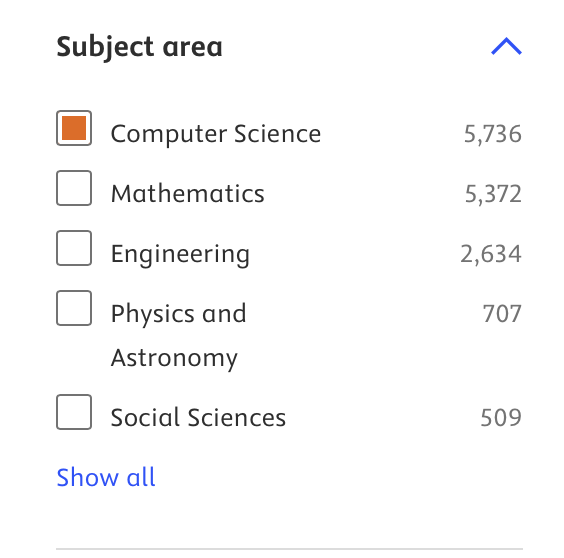

##Cleaning Data (ทำความสะอาดข้อมูล)

### ตรวจสอบความซ้ำซ้อนของข้อมูล (Remove Duplicate)

* เมื่อดาวน์โหลดข้อมูลครบถ้วน ให้ตรวจสอบความซ้ำซ้อนของบทความ
* 1 บทความควรอยู่ได้เฉพาะ 1 Subject เท่านั้น ตัวอย่างเช่น หากค้นพบบทความรหัส `A15` ใน subject `Artificial Intelligence` ดังนั้นบทความรหัส `A15` จะปรากฎใน subject อื่นอีกไม่ได้
* หากพบว่า `A15` ปรากฎใน subject เช่น `Artificial Intelligence` และ `Software` ให้ลบบทความรหัส `A15` ออกจากทั้งสอง subject

### ตรวจสอบข้อมูลที่ไม่เกี่ยวข้อง

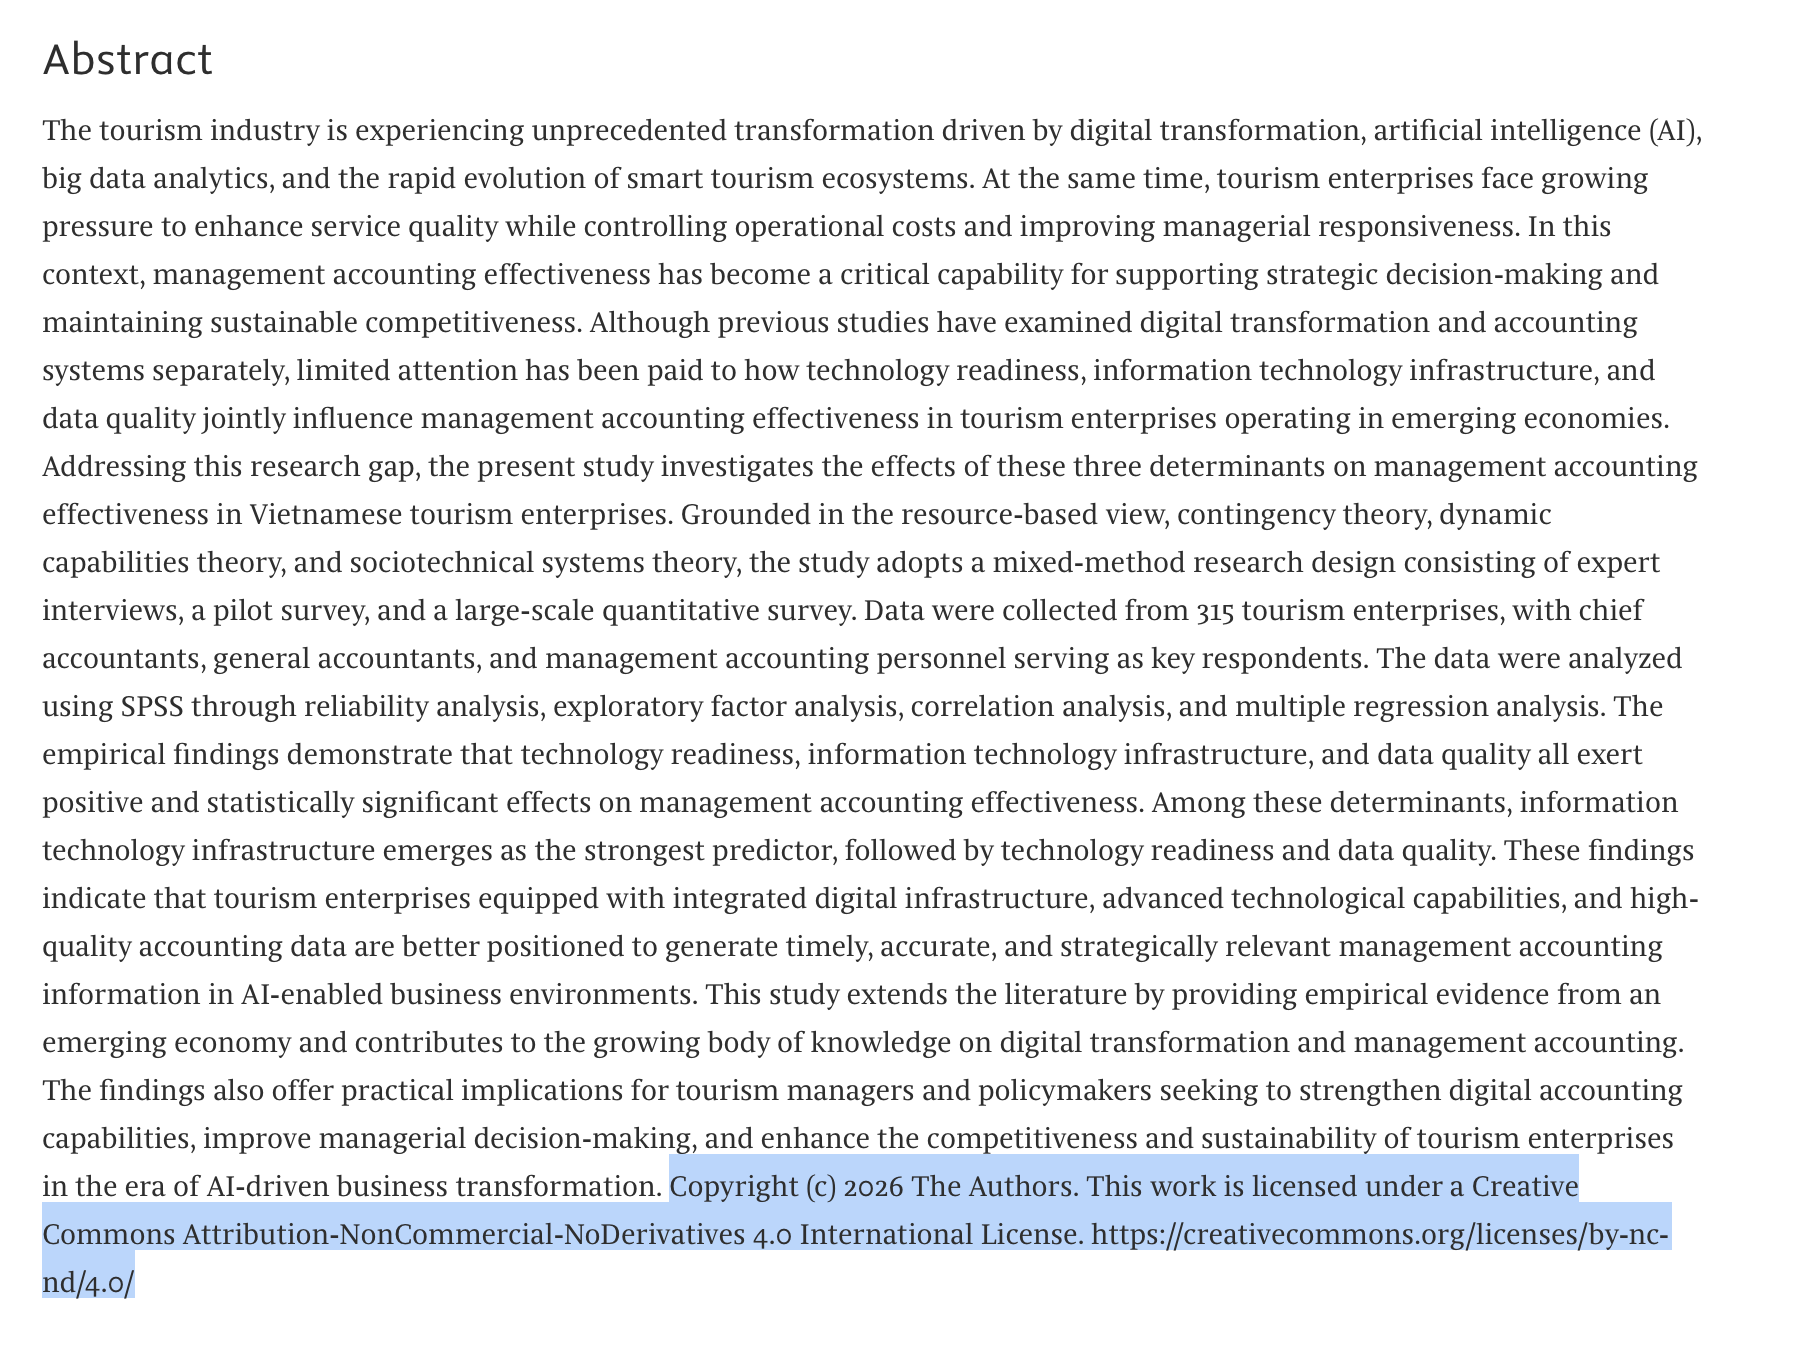

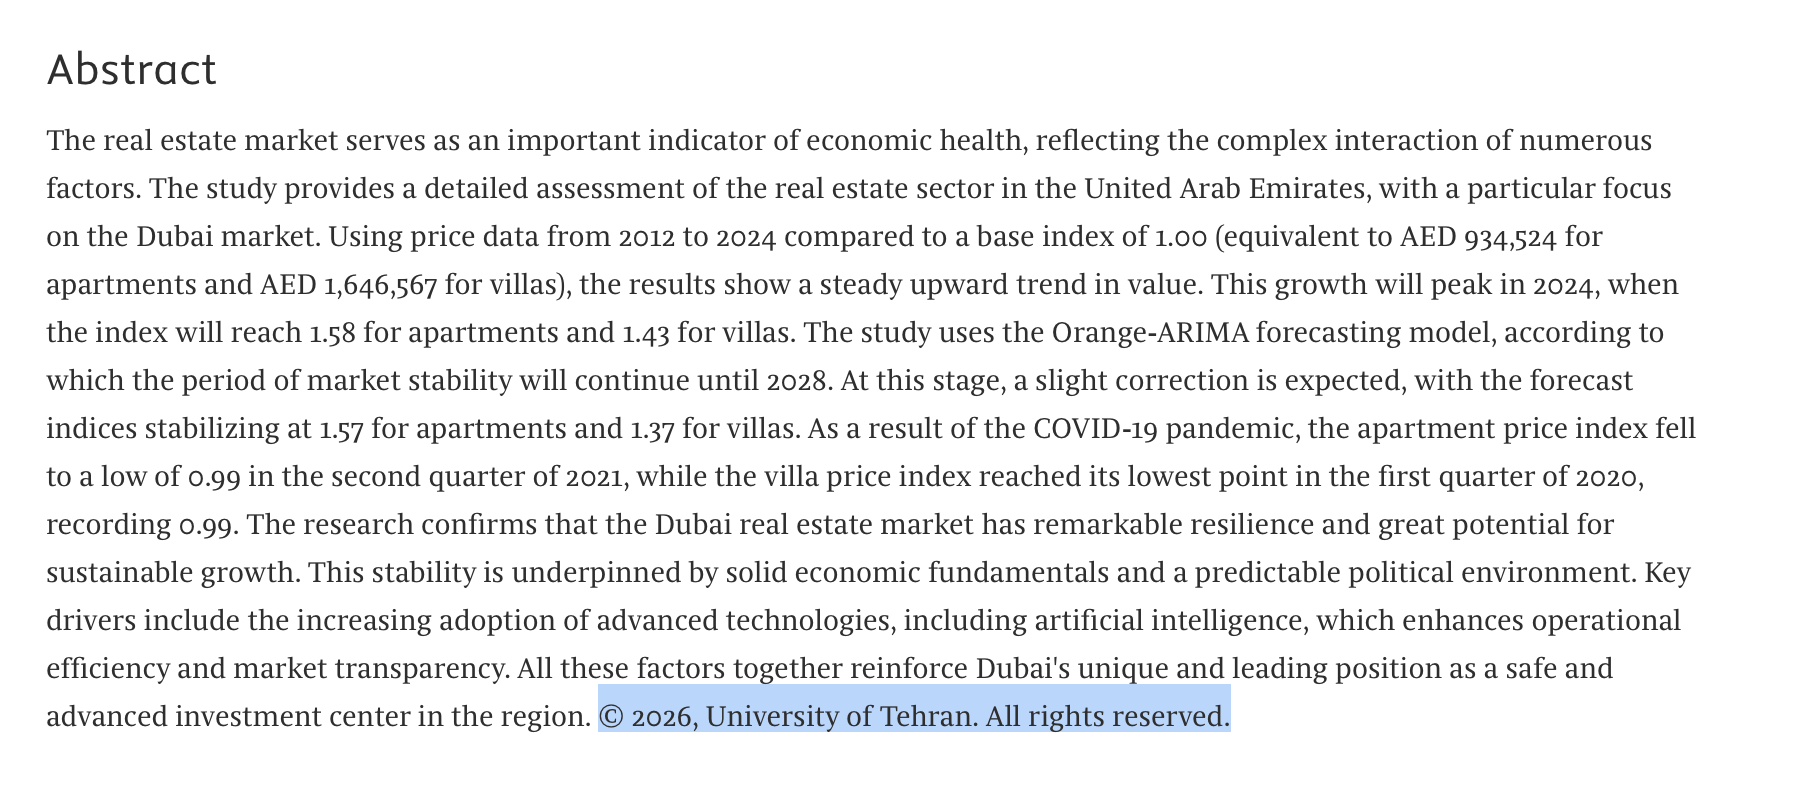

ตัวอย่างเช่น ใน `Abstract` อาจมีเนื้อหาที่ไม่เกี่ยวข้อง เช่น

```
Copyright (c) 2026 The Authors. This work is licensed under a Creative
Commons Attribution-NonCommercial-NoDerivatives 4.0 International License.
https://creativecommons.org/licenses/by-nc-nd/4.0/
```

```
© 2026, University of Tehran. All rights reserved.
```

* หรือบางครั้ง `title` มีเนื้อหาในภาษาอื่นที่ไม่ใช่ อังกฤษ

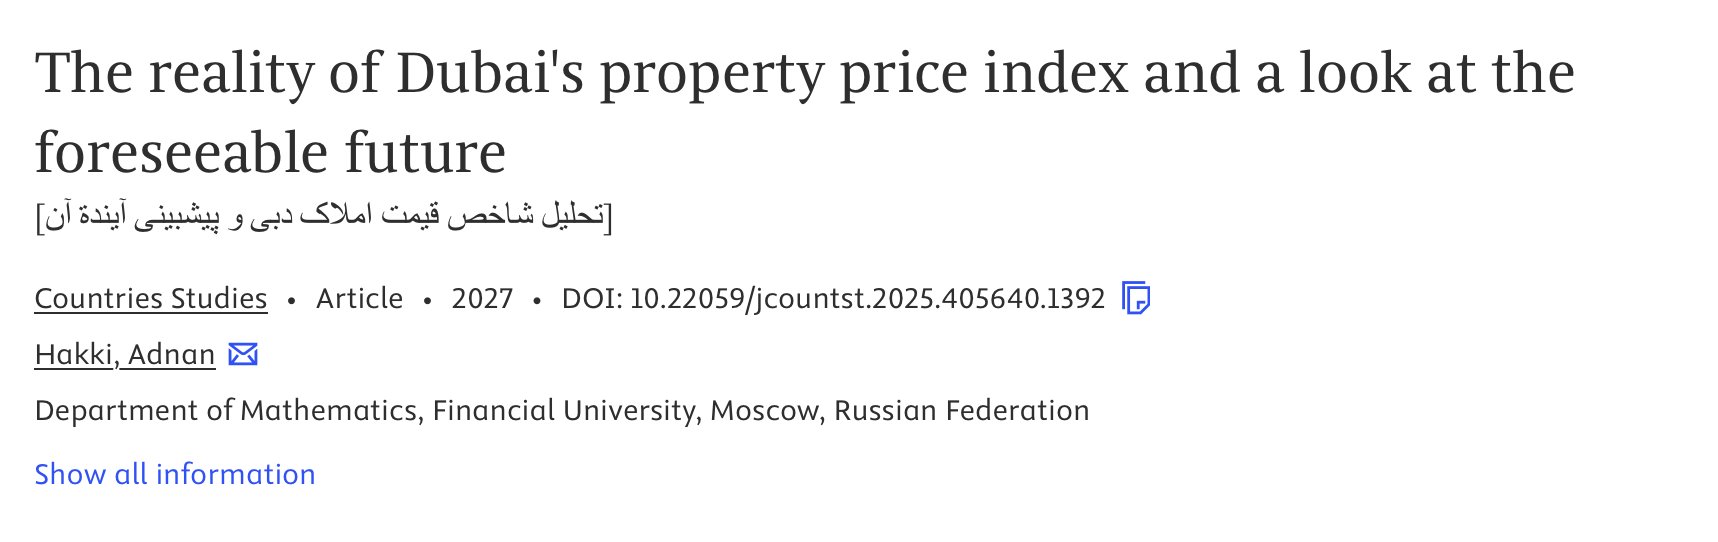

จากตัวอย่างข้างต้น เป็นตัวอย่างของการเตรียมข้อมูล เพื่อนำไปใช้สำหรับการสร้างโมเดลของ `Machine Learning`

* สิ่งที่นิสิตสามารถทำเพิ่มเติมได้ เช่น ค้นหา Missing Value, ทำ word cloud เพื่อดู `keyword` ที่ปรากฎในแต่ละ `subject`

* คัดเลือกคอลัมน์ที่เหมาะสมกับการนำมาสร้าง `feature vector`

* ทำ Data Visualization

# สร้าง Feature Vector

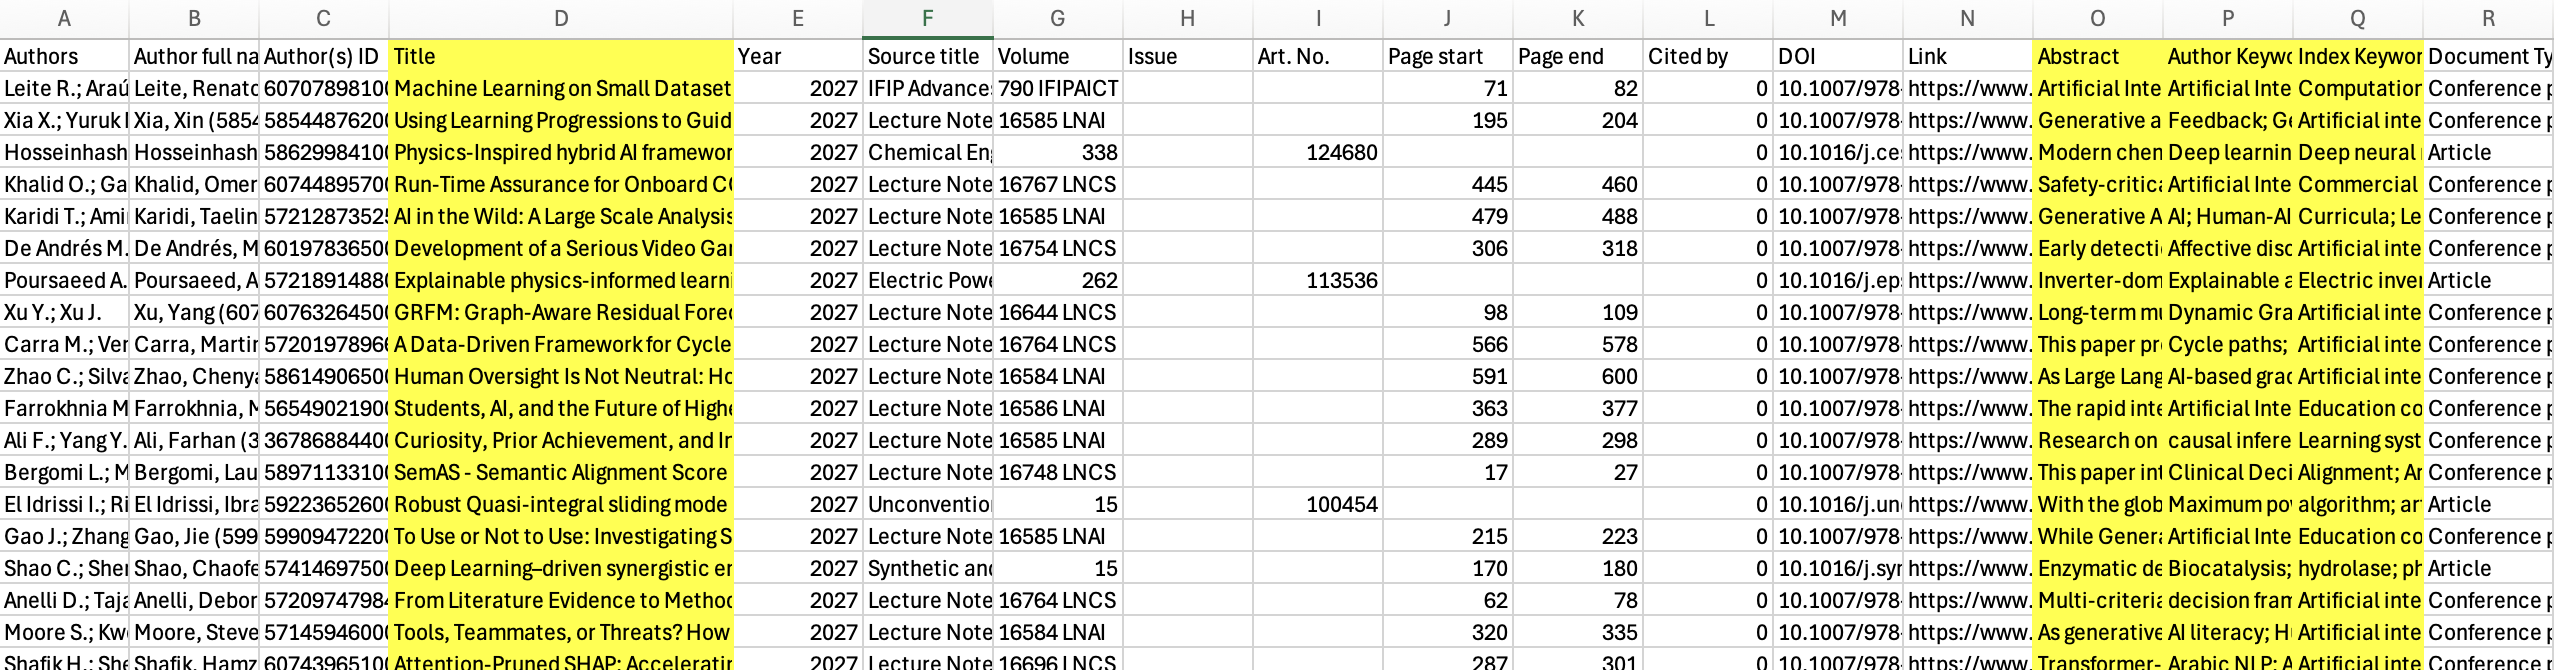

* จากตัวอย่างจะเลือก `Title`, `Abstract`, `Author Keyword`, `Index Keyword`

ดังนั้นจะต้องแปลงข้อมูล ดังนี้
```
Title: Machine Learning on Small Datasets Under
Resource Constrained: A Scoping Review
```

```
Abstract: Artificial Intelligence AI is increasingly
present in daily life, driven mainly by applications based
on Large Language Models LLMs, trained on massive volumes
of data. Although successful, this new generation of
solutions has evidenced limitations related to applications
in which data are limited and computational capacities are
constrained. This scenario is more critical particularly in
embedded systems and industrial application contexts. This
work presents a scoping review, conducted according to the
Preferred Reporting Items for Systematic Reviews and
Meta-Analyses Extension for Scoping Reviews (PRISMA-ScR),
with the objective of mapping the state of the art of
strategies, techniques, and architectures of machine
learning, deep learning, and reinforcement learning applied
to scenarios with small datasets and limited resources. The
findings show hybrid approaches, data-oriented strategies,
and the centrality of computational efficiency, indicating
an emergence of reinforcement learning for research on
structured mechanism to generate synthetic data on sparse
data scenarios.
```

```
Author keywords: Artificial Intelligence; Embedded Systems;
Machine Learning; Reinforcement Learning;
Resource-constrained Environments; Small Datasets
```

```
Index Keywords:
Computational efficiency; Deep learning; Embedded software;
Information systems; Information use; Learning systems;
Daily lives; Embedded-system; Generation of solutions;
Language model; Limited capacity; Machine-learning;
Reinforcement learnings; Resource-constrained environment;
Scoping review; Small data set; Embedded systems
```

และนำข้อมูลข้างต้นมารวมกันก่อนที่จะส่งเข้า Algorithm เช่น `TF-IDF`, `BERTa` เพื่อทำ Text Embedding

อ่าน csv

In [ ]:
import pandas as pd

# กำหนดตำแหน่งไฟล์ CSV
file_path = "scopus.csv"

# อ่านไฟล์ CSV
df = pd.read_csv(file_path)

# เลือกเฉพาะคอลัมน์ที่ต้องการ
selected_columns = [
    "Title",
    "Abstract",
    "Author Keywords",
    "Index Keywords"
]

selected_df = df[selected_columns]

# แสดงจำนวนข้อมูลและตัวอย่าง 5 รายการแรก
print("จำนวนบทความ:", len(selected_df))
display(selected_df.head())

จำนวนบทความ: 200


,Title,Abstract,Author Keywords,Index Keywords
0,Multi-joint collaborative control for selectiv...,Robotic milling has emerged as a cost-effectiv...,Dynamic coupling; Low-frequency chatter; Multi...,Actuators; Control system synthesis; Controlle...
1,ARetinex-Net: Low-light image enhancement with...,Low-light image enhancement (LLIE) aims to imp...,Low-light image enhancement; Retinex model; Ve...,Arts computing; Benchmarking; Vector quantizat...
2,q-Parametric Bézier-driven functional Kolmogor...,Recent advances in Kolmogorov–Arnold Networks ...,Functional learning; Geometric deep learning; ...,Convolution; Data mining; Deep learning; Geome...
3,DKGCN: Entity alignment based on dynamic graph...,"In e-commerce platforms, given the dynamic cha...",Dynamic graph neural networks; E-commerce; Ent...,Alignment; Data mining; Dynamics; Embeddings; ...
4,AdapHBNA: Adaptive hierarchical spatio-tempora...,Brain Network Analysis (BNA) from resting-stat...,Brain disease diagnosis; Brain network analysi...,Brain; Computer aided diagnosis; Diseases; Hie...


เปลี่ยนชื่อ column ให้เหมาะสม

In [ ]:
selected_df = selected_df.rename(
    columns={
        "Title": "title",
        "Abstract": "abstract",
        "Author Keywords": "author_keywords",
        "Index Keywords": "index_keywords"
    }
)

display(selected_df.head())

,title,abstract,author_keywords,index_keywords
0,Multi-joint collaborative control for selectiv...,Robotic milling has emerged as a cost-effectiv...,Dynamic coupling; Low-frequency chatter; Multi...,Actuators; Control system synthesis; Controlle...
1,ARetinex-Net: Low-light image enhancement with...,Low-light image enhancement (LLIE) aims to imp...,Low-light image enhancement; Retinex model; Ve...,Arts computing; Benchmarking; Vector quantizat...
2,q-Parametric Bézier-driven functional Kolmogor...,Recent advances in Kolmogorov–Arnold Networks ...,Functional learning; Geometric deep learning; ...,Convolution; Data mining; Deep learning; Geome...
3,DKGCN: Entity alignment based on dynamic graph...,"In e-commerce platforms, given the dynamic cha...",Dynamic graph neural networks; E-commerce; Ent...,Alignment; Data mining; Dynamics; Embeddings; ...
4,AdapHBNA: Adaptive hierarchical spatio-tempora...,Brain Network Analysis (BNA) from resting-stat...,Brain disease diagnosis; Brain network analysi...,Brain; Computer aided diagnosis; Diseases; Hie...


สร้าง text embedding ให้รวม Title, Abstract, Author Keywords และ Index Keywords เป็นข้อความเดียว โดยรักษาความหมายของแต่ละส่วนด้วยคำกำกับ เช่น Title: และ Abstract:

In [ ]:
def combine_text(row):
    text_parts = []

    if row["title"]:
        text_parts.append(f"Title: {row['title']}")

    if row["abstract"]:
        text_parts.append(f"Abstract: {row['abstract']}")

    if row["author_keywords"]:
        text_parts.append(
            f"Author keywords: {row['author_keywords']}"
        )

    if row["index_keywords"]:
        text_parts.append(
            f"Index keywords: {row['index_keywords']}"
        )

    return "\n".join(text_parts)


selected_df["embedding_text"] = selected_df.apply(
    combine_text,
    axis=1
)

display(selected_df[["embedding_text"]].head())

,embedding_text
0,Title: Multi-joint collaborative control for s...
1,Title: ARetinex-Net: Low-light image enhanceme...
2,Title: q-Parametric Bézier-driven functional K...
3,Title: DKGCN: Entity alignment based on dynami...
4,Title: AdapHBNA: Adaptive hierarchical spatio-...


นำ `selected_df` ไปสร้าง `document embeddings` ด้วย `SPECTER2 proximity adapter`

SPECTER2 ใช้ Title [SEP] Abstract เป็นข้อมูลนำเข้าตามรูปแบบทางการของโมเดล

ข้อควรทราบคือ SPECTER2 รับข้อความสูงสุด 512 tokens ดังนั้นข้อความที่ยาวเกินขอบเขตจะถูกตัดท้ายออก เนื่องจาก Author keywords และ Index keywords อยู่ท้ายข้อความ จึงมีโอกาสถูกตัดออกในบทความที่มี Abstract ยาวมาก แต่ embedding ยังสร้างได้ตามปกติ

ติดตั้งไลบรารี

In [ ]:
!pip install -q -U transformers adapters tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.5/295.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


โหลด SPECTER2

In [ ]:
import torch
import numpy as np

from tqdm.auto import tqdm
from transformers import AutoTokenizer
from adapters import AutoAdapterModel

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# โหลด tokenizer และ base model
tokenizer = AutoTokenizer.from_pretrained(
    "allenai/specter2_base"
)

model = AutoAdapterModel.from_pretrained(
    "allenai/specter2_base"
)

# Proximity adapter สำหรับ similarity, clustering และ retrieval
model.load_adapter(
    "allenai/specter2",
    source="hf",
    load_as="proximity",
    set_active=True
)

model = model.to(device)
model.eval()

print("โหลด SPECTER2 เรียบร้อยแล้ว")

Device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

adapter_config.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

pytorch_adapter.bin:   0%|          | 0.00/3.59M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

โหลด SPECTER2 เรียบร้อยแล้ว


In [ ]:
texts = selected_df["embedding_text"].tolist()

print("จำนวนข้อความ:", len(texts))
print("\nตัวอย่างข้อความแรก:")
print(texts[0])

จำนวนข้อความ: 200

ตัวอย่างข้อความแรก:
Title: Multi-joint collaborative control for selective suppression of low-frequency chatter in robotic milling considering dynamic coupling
Abstract: Robotic milling has emerged as a cost-effective and flexible solution for machining large-scale complex components, yet its productivity is severely bottlenecked by low-frequency chatter (LFC) induced by joint flexibility. Existing joint-based vibration suppression strategies are typically confined to the Independent Joint Control (IJC) framework, which neglects inter-joint dynamic coupling and models each joint as an isolated single-input-single-output (SISO) system. Neglecting inter-joint dynamic coupling introduces massive unstructured modeling errors, forcing IJC-based H∞ controllers into extreme performance conservatism to guarantee robustness. Conversely, IJC-based DVF controller (or decentralized viscous damper) is inherently velocity-dependent, rendering it hypersensitive to high-frequency vi

ตรวจสอบว่าข้อมูลทั้งหมดเป็น string:

In [ ]:
texts = (
    selected_df["embedding_text"]
    .fillna("")
    .astype(str)
    .tolist()
)

สร้าง SPECTER2 Embeddings

In [ ]:
def create_specter2_embeddings(
    texts,
    model,
    tokenizer,
    device,
    batch_size=16,
    max_length=512
):
    all_embeddings = []

    for start_index in tqdm(
        range(0, len(texts), batch_size),
        desc="Creating SPECTER2 embeddings"
    ):
        batch_texts = texts[
            start_index:start_index + batch_size
        ]

        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
            return_token_type_ids=False
        )

        inputs = {
            key: value.to(device)
            for key, value in inputs.items()
        }

        with torch.inference_mode():
            outputs = model(**inputs)

        # ใช้ representation ของ token แรก
        batch_embeddings = (
            outputs.last_hidden_state[:, 0, :]
            .detach()
            .cpu()
            .numpy()
        )

        all_embeddings.append(batch_embeddings)

    return np.vstack(all_embeddings)

เรียกใช้งาน

In [ ]:
specter2_embeddings = create_specter2_embeddings(
    texts=texts,
    model=model,
    tokenizer=tokenizer,
    device=device,
    batch_size=16,
    max_length=512
)

print("Embedding shape:", specter2_embeddings.shape)

Creating SPECTER2 embeddings:   0%|          | 0/13 [00:00<?, ?it/s]

Embedding shape: (200, 768)


In [ ]:
specter2_embeddings[0]

array([ 1.74381554e-01,  9.57309902e-01, -4.40659434e-01,  1.20025194e+00,
        1.41271159e-01,  6.04654290e-03,  5.26091576e-01, -3.58811915e-01,
        3.70722204e-01, -5.81867158e-01,  4.55533892e-01,  4.23160754e-02,
       -4.51566875e-01, -1.21670337e-02, -3.23520511e-01, -6.05470419e-01,
       -1.09598732e+00,  2.07727030e-01, -1.06842101e-01, -2.09391832e-01,
        1.49334341e-01, -4.49626893e-01, -3.35128129e-01, -3.23442400e-01,
        8.78294557e-02,  6.97015882e-01,  2.86684990e-01,  6.63577557e-01,
       -1.69384614e-01,  9.28369343e-01,  4.37812597e-01,  2.08748892e-01,
        6.67309701e-01,  1.58156186e-01, -2.76707858e-01,  8.67987797e-02,
       -1.24401063e-01, -1.71093643e-01, -5.82658611e-02,  6.13175392e-01,
       -1.98029488e-01,  9.44165140e-02,  8.17669272e-01, -4.57620412e-01,
       -7.62417987e-02,  2.76995420e-01, -1.46092057e-01,  1.80382971e-02,
       -3.08922380e-01, -4.56521124e-01,  5.23670971e-01, -6.31871581e-01,
        1.66404173e-01,  

Normalize Embeddings

In [ ]:
from sklearn.preprocessing import normalize

specter2_embeddings_normalized = normalize(
    specter2_embeddings,
    norm="l2"
)

print(
    "Normalized embedding shape:",
    specter2_embeddings_normalized.shape
)

Normalized embedding shape: (200, 768)


In [ ]:
specter2_embeddings_normalized[0]

array([ 7.94127956e-03,  4.35955822e-02, -2.00674888e-02,  5.46590835e-02,
        6.43344270e-03,  2.75357597e-04,  2.39580404e-02, -1.63401775e-02,
        1.68825686e-02, -2.64980420e-02,  2.07448658e-02,  1.92706042e-03,
       -2.05642097e-02, -5.54082799e-04, -1.47330193e-02, -2.75729261e-02,
       -4.99109067e-02,  9.45982151e-03, -4.86555463e-03, -9.53563582e-03,
        6.80063758e-03, -2.04758625e-02, -1.52616268e-02, -1.47294626e-02,
        3.99972498e-03,  3.17418762e-02,  1.30555416e-02,  3.02191079e-02,
       -7.71372067e-03,  4.22776379e-02,  1.99378431e-02,  9.50635690e-03,
        3.03890686e-02,  7.20238173e-03, -1.26011865e-02,  3.95278819e-03,
       -5.66518400e-03, -7.79154897e-03, -2.65340856e-03,  2.79238094e-02,
       -9.01819859e-03,  4.29969747e-03,  3.72363925e-02, -2.08398849e-02,
       -3.47202690e-03,  1.26142818e-02, -6.65298477e-03,  8.21458234e-04,
       -1.40682254e-02, -2.07898244e-02,  2.38478072e-02, -2.87752263e-02,
        7.57799204e-03,  